In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load dataset
df = pd.read_csv("../data/marketing_data.csv")
df['week_start'] = pd.to_datetime(df['week_start'])
df = df.sort_values('week_start').reset_index(drop=True)

# Set global plot styling
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

print("Data loaded successfully! Total records:", len(df))

Data loaded successfully! Total records: 130


In [3]:
# 1. Summary Statistics
numeric_cols = ['total_revenue', 'meta_spend', 'google_spend', 'tv_spend']
summary_stats = df[numeric_cols].describe().T
summary_stats['skewness'] = df[numeric_cols].skew()
summary_stats['kurtosis'] = df[numeric_cols].kurtosis()
summary_stats['iqr'] = summary_stats['75%'] - summary_stats['25%']

print("--- Distribution Summary Statistics ---")
display(summary_stats[['mean', 'std', 'min', '50%', 'max', 'iqr', 'skewness', 'kurtosis']])

# 2. Channel Flighting (Zero-Spend Weeks)
print("\n--- Zero-Spend Weeks (Channel Flighting Analysis) ---")
for col in ['meta_spend', 'google_spend', 'tv_spend']:
    zero_weeks = (df[col] == 0).sum()
    pct_zero = (zero_weeks / len(df)) * 100
    print(f"{col}: {zero_weeks} zero-spend weeks ({pct_zero:.1f}% off-air)")

--- Distribution Summary Statistics ---


,mean,std,min,50%,max,iqr,skewness,kurtosis
total_revenue,141836.000769,43083.276047,70850.11,131994.520,263190.14,62465.8525,0.543525,-0.252319
meta_spend,9266.147077,3291.461062,4060.74,9313.055,14855.76,6264.1350,0.071411,-1.333753
google_spend,7516.673000,2647.580419,3045.55,7638.980,11870.85,4342.8650,0.031062,-1.236173
tv_spend,10085.301538,16824.004543,0.00,0.000,49618.28,22682.9350,1.248218,-0.111411



--- Zero-Spend Weeks (Channel Flighting Analysis) ---
meta_spend: 0 zero-spend weeks (0.0% off-air)
google_spend: 0 zero-spend weeks (0.0% off-air)
tv_spend: 93 zero-spend weeks (71.5% off-air)


In [4]:
# 3. Variance Inflation Factor (VIF)
X_vif = df[['meta_spend', 'google_spend', 'tv_spend']].copy()
X_vif['intercept'] = 1.0

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns[:-1]
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1]-1)]

print("--- Variance Inflation Factor (VIF) ---")
display(vif_data)

# 4. Cross-Correlation Lags
lags = range(0, 6)
corrs = [df['total_revenue'].corr(df['tv_spend'].shift(lag)) for lag in lags]

print("\n--- TV Spend Lag Correlation Structure ---")
for lag, corr in zip(lags, corrs):
    print(f"TV Spend Lag {lag} Weeks -> Correlation with Revenue: {corr:.3f}")

--- Variance Inflation Factor (VIF) ---


,Variable,VIF
0,meta_spend,1.002068
1,google_spend,1.004715
2,tv_spend,1.004663



--- TV Spend Lag Correlation Structure ---
TV Spend Lag 0 Weeks -> Correlation with Revenue: 0.737
TV Spend Lag 1 Weeks -> Correlation with Revenue: 0.471
TV Spend Lag 2 Weeks -> Correlation with Revenue: 0.310
TV Spend Lag 3 Weeks -> Correlation with Revenue: 0.171
TV Spend Lag 4 Weeks -> Correlation with Revenue: 0.087
TV Spend Lag 5 Weeks -> Correlation with Revenue: 0.065


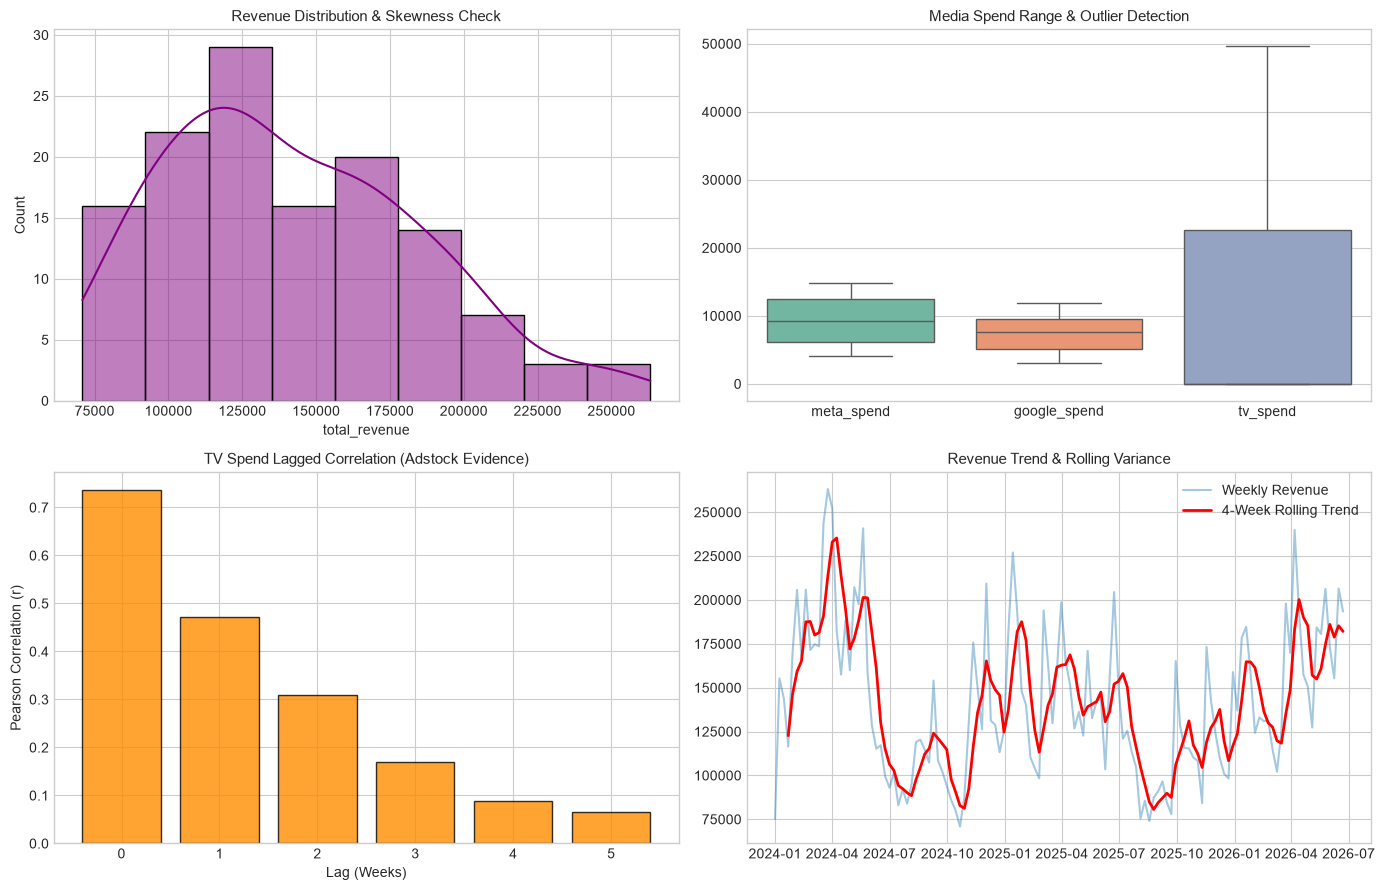

In [5]:
# 5. Visual EDA Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Plot A: Revenue Skewness
sns.histplot(df['total_revenue'], kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title("Revenue Distribution & Skewness Check", fontsize=11)

# Plot B: Spend Outliers
sns.boxplot(data=df[['meta_spend', 'google_spend', 'tv_spend']], ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Media Spend Range & Outlier Detection", fontsize=11)

# Plot C: Adstock Lag Structure
axes[1, 0].bar(lags, corrs, color='darkorange', edgecolor='black', alpha=0.8)
axes[1, 0].set_title("TV Spend Lagged Correlation (Adstock Evidence)", fontsize=11)
axes[1, 0].set_xlabel("Lag (Weeks)")
axes[1, 0].set_ylabel("Pearson Correlation (r)")

# Plot D: Revenue Trend & Rolling Average
df['revenue_rolling_4w'] = df['total_revenue'].rolling(window=4).mean()
axes[1, 1].plot(df['week_start'], df['total_revenue'], alpha=0.4, label='Weekly Revenue')
axes[1, 1].plot(df['week_start'], df['revenue_rolling_4w'], color='red', linewidth=2, label='4-Week Rolling Trend')
axes[1, 1].set_title("Revenue Trend & Rolling Variance", fontsize=11)
axes[1, 1].legend()

plt.tight_layout()
plt.show()